In [5]:
# !pip install --quiet duckdb pandas pyarrow matplotlib seaborn
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [ ]:
from pathlib import Path

db_path = Path(r"C:\Users\Nebula PC\Swinburne\Intern\boxai\data\numero.duckdb")
assert db_path.exists(), f"DB not found: {db_path}"

con = duckdb.connect(database=str(db_path))

tables_df = con.sql("SHOW TABLES").df()
tables_df

,name
0,films_raw


In [7]:

table_name = tables_df.loc[0, 'name'] if 'name' in tables_df.columns and len(tables_df) else None
if table_name is None:
    raise ValueError("No tables found. Check your database.")

df = con.table(table_name).df()  # load selected table

# Basic inspection
print(f"Loaded table: {table_name} with shape {df.shape}")
display(df.head())
display(df.info())
display(df.describe(include='all'))

Loaded table: films_raw with shape (135, 3)


,week_date,data,filename
0,2023-01-05,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2023-01-05.json
1,2023-01-12,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2023-01-12.json
2,2023-01-19,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2023-01-19.json
3,2023-01-26,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2023-01-26.json
4,2023-02-02,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2023-02-02.json


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   week_date  135 non-null    datetime64[us]
 1   data       135 non-null    object        
 2   filename   135 non-null    object        
dtypes: datetime64[us](1), object(2)
memory usage: 3.3+ KB


None

,week_date,data,filename
count,135,135,135
unique,NaN,135,135
top,NaN,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2023-01-05.json
freq,NaN,1,1
mean,2024-04-18 00:00:00,NaN,NaN
min,2023-01-05 00:00:00,NaN,NaN
25%,2023-08-27 12:00:00,NaN,NaN
50%,2024-04-18 00:00:00,NaN,NaN
75%,2024-12-08 12:00:00,NaN,NaN
max,2025-07-31 00:00:00,NaN,NaN


In [8]:
con.sql(f"DESCRIBE {table_name}").df()

,column_name,column_type,null,key,default,extra
0,week_date,DATE,YES,None,None,None
1,data,JSON,YES,None,None,None
2,filename,VARCHAR,YES,None,None,None


In [9]:

try:
    df  
except NameError:
    tabs = con.sql("SHOW TABLES").df()
    names = tabs['name'].tolist() if 'name' in tabs.columns else []
    preferred = None
    if 'table_name' in globals() and isinstance(table_name, str):
        if f"{table_name}_cleaned" in names:
            preferred = f"{table_name}_cleaned"
        elif table_name in names:
            preferred = table_name
    if preferred is None and names:
        preferred = names[0]
    if preferred is None:
        raise ValueError("No tables found to load into df. Run the load cell or set table_name.")
    df = con.table(preferred).df()
    table_name = preferred
    print(f"Loaded table for EDA: {table_name} shape={df.shape}")

df_flat = df.copy()  # already cleaned in DataGrip

for c in df_flat.select_dtypes(include=['object']).columns:
    df_flat[c] = df_flat[c].astype(str).str.strip()


df_flat = df_flat.loc[:, ~df_flat.columns.duplicated()]

df_flat = df_flat.drop_duplicates()

print("After cleaning shape:", df_flat.shape)
display(df_flat.head())

#  Nulls overview
nulls = df_flat.isna().mean().sort_values(ascending=False)
display(nulls.head(30))

#  Cardinality of object
card = df_flat.select_dtypes(include=['object']).nunique().sort_values(ascending=False)
display(card.head(30))

#  Numeric distributions
num_cols = df_flat.select_dtypes(include=['number']).columns.tolist()
if num_cols:
    display(df_flat[num_cols].describe().T)

#  Correlations 
if len(num_cols) >= 2:
    corr = df_flat[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(min(12, 1 + 0.5*len(num_cols)), min(10, 1 + 0.5*len(num_cols))))
    sns.heatmap(corr, cmap='vlag', center=0)
    plt.title('Correlation heatmap')
    plt.show()



After cleaning shape: (135, 3)


,week_date,data,filename
0,2023-01-05,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2023-01-05.json
1,2023-01-12,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2023-01-12.json
2,2023-01-19,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2023-01-19.json
3,2023-01-26,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2023-01-26.json
4,2023-02-02,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2023-02-02.json


week_date    0.0
data         0.0
filename     0.0
dtype: float64

data        135
filename    135
dtype: int64

## Visualize

- Missing values by column
- Distributions of numeric features
- Top categories for categorical features


C:\Users\tiendungp\AppData\Local\Temp\ipykernel_29232\1277241758.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=miss.values, y=miss.index, orient='h', palette='Blues_r')


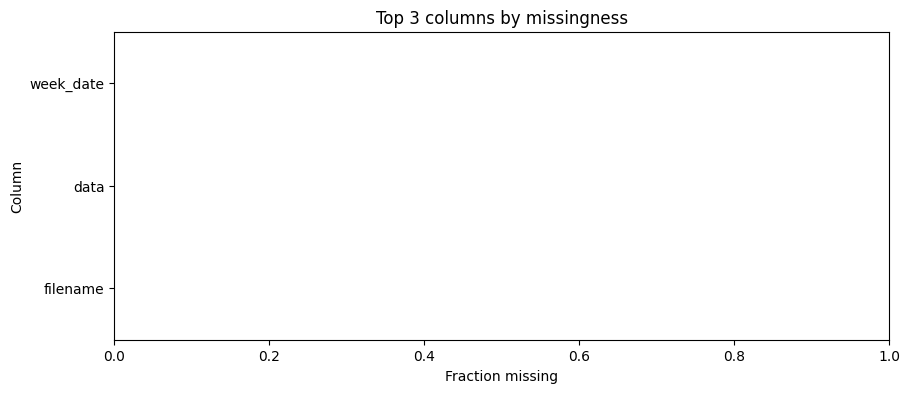

In [10]:
# Missingness by column 
top_n = 20
miss = df_flat.isna().mean().sort_values(ascending=False).head(top_n)
plt.figure(figsize=(10, max(4, 0.3*len(miss))))
sns.barplot(x=miss.values, y=miss.index, orient='h', palette='Blues_r')
plt.xlabel('Fraction missing')
plt.ylabel('Column')
plt.title(f'Top {len(miss)} columns by missingness')
plt.xlim(0, 1)
plt.show()

In [15]:
# Numeric distributions 
num_cols = df_flat.select_dtypes(include=['number']).columns.tolist()
if num_cols:
    sample = df_flat[num_cols]
    if len(sample) > 50000:
        sample = sample.sample(50000, random_state=42)
    k = len(num_cols)
    cols = 3
    rows = int(np.ceil(k/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*3))
    axes = axes.flatten() if k > 1 else [axes]
    for i, c in enumerate(num_cols):
        sns.histplot(sample[c], ax=axes[i], kde=False, bins=30, color='#4477AA')
        axes[i].set_title(c)
    for j in range(i+1, rows*cols):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()
else:
    print('No numeric columns found for histograms.')
# may not be needed 

No numeric columns found for histograms.


In [12]:
#  Top categories for categorical columns 
all_cats = df_flat.select_dtypes(include=['object']).columns.tolist()
norm_cols = [c for c in all_cats if c.endswith('_norm')]
#  Specific columns 
force_include = ['censor_rating']
forced_cols = [c for c in all_cats if c in force_include]
cat_cols = list(dict.fromkeys(norm_cols + forced_cols))  
top_k = 15
if cat_cols:
    for c in cat_cols[:10]:  # limit to first 10 categorical columns to keep it quick
        vc = df_flat[c].astype(str).value_counts(dropna=False).head(top_k)
        plt.figure(figsize=(8, max(3, 0.3*len(vc))))
        sns.barplot(x=vc.values, y=vc.index, orient='h', palette='Greens_r')
        plt.title(f"Top {len(vc)} values: {c}")
        plt.xlabel('Count')
        plt.ylabel(c)
        plt.show()
else:
    print("No categorical *_norm columns (or forced includes) found for top-k plots.")

No categorical *_norm columns (or forced includes) found for top-k plots.


In [14]:
df_flat

,week_date,data,filename
0,2023-01-05,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2023-01-05.json
1,2023-01-12,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2023-01-12.json
2,2023-01-19,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2023-01-19.json
3,2023-01-26,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2023-01-26.json
4,2023-02-02,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2023-02-02.json
...,...,...,...
130,2025-07-03,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2025-07-03.json
131,2025-07-10,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2025-07-10.json
132,2025-07-17,"{""films"":[{""censorRating"":""M"",""distributorId"":...",2025-07-17.json
133,2025-07-24,"{""films"":[{""censorRating"":""PG"",""distributorId""...",2025-07-24.json


In [13]:
# Top movies by revenue 
def first_present(cands):
    return next((c for c in cands if c in df_flat.columns), None)

title_col = first_present(['title_norm','title','film_title','movie_title','title_name']) or first_present(['film_id','movie_id'])
week_col = first_present(['week','play_week','week_number','week_num','date','week_end_date'])
rev_week_col = first_present(['gross_weekend','weekend_gross','gross_week','gross','revenue_weekend'])
rev_cume_col = first_present(['cumulative_gross_weekend','cume_gross_weekend','total_gross','lifetime_gross'])
rev_final_col = first_present(['gross_weekend_final','weekend_gross_final'])

if title_col is None:
    raise ValueError("Could not find a title or id column to group by.")

print('Using columns -> title:', title_col, '| weekly:', rev_week_col, '| cumulative:', rev_cume_col, '| final:', rev_final_col)

# Top by cumulative total
if rev_cume_col:
    top_cume = (df_flat.groupby(title_col, dropna=False)[rev_cume_col]
                .max().sort_values(ascending=False).head(10))
    display(top_cume.to_frame(name='cumulative_total'))
else:
    print('No cumulative column found; skipping cumulative toplist.')

# Top by sum of weekly gross 
if rev_week_col:
    top_sum = (df_flat.groupby(title_col, dropna=False)[rev_week_col]
               .sum().sort_values(ascending=False).head(10))
    display(top_sum.to_frame(name='sum_weekly_gross'))
else:
    print('No weekly gross column found; skipping weekly-sum toplist.')

# Top by best single-weekend peak
if rev_week_col:
    top_peak = (df_flat.groupby(title_col, dropna=False)[rev_week_col]
                .max().sort_values(ascending=False).head(10))
    display(top_peak.to_frame(name='peak_single_weekend'))

# Show details for the top title from the best available metric
winner = None
if rev_cume_col and not (df_flat[rev_cume_col].dropna().empty):
    winner = top_cume.index[0]
elif rev_week_col:
    winner = top_sum.index[0] if 'top_sum' in locals() else top_peak.index[0]

if winner is not None:
    print("Winner:", winner)
    detail_cols = [c for c in [title_col, week_col, rev_week_col, rev_cume_col, rev_final_col] if c]
    df_detail = df_flat.loc[df_flat[title_col] == winner, detail_cols].copy()
    if week_col and np.issubdtype(df_detail[week_col].dtype, np.datetime64):
        df_detail = df_detail.sort_values(week_col)
    elif week_col:
        df_detail = df_detail.sort_values(week_col, kind='mergesort')
    display(df_detail.head(20))

ValueError: Could not find a title or id column to group by.

## Top movies by revenue 
- Top 10 by cumulative total 
- Top 10 by sum of weekly gross
- Top 10 by best single-weekend peak
- A simple time series for the top title

C:\Users\Nebula PC\AppData\Local\Temp\ipykernel_15116\1826029994.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=s_scaled.values, y=s_scaled.index, orient='h', palette='mako')


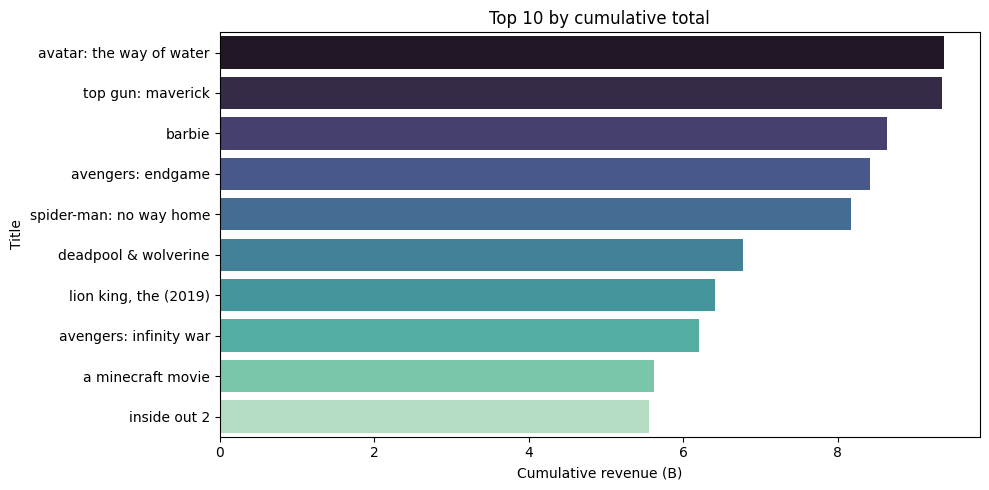

C:\Users\Nebula PC\AppData\Local\Temp\ipykernel_15116\1826029994.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=s_scaled.values, y=s_scaled.index, orient='h', palette='mako')


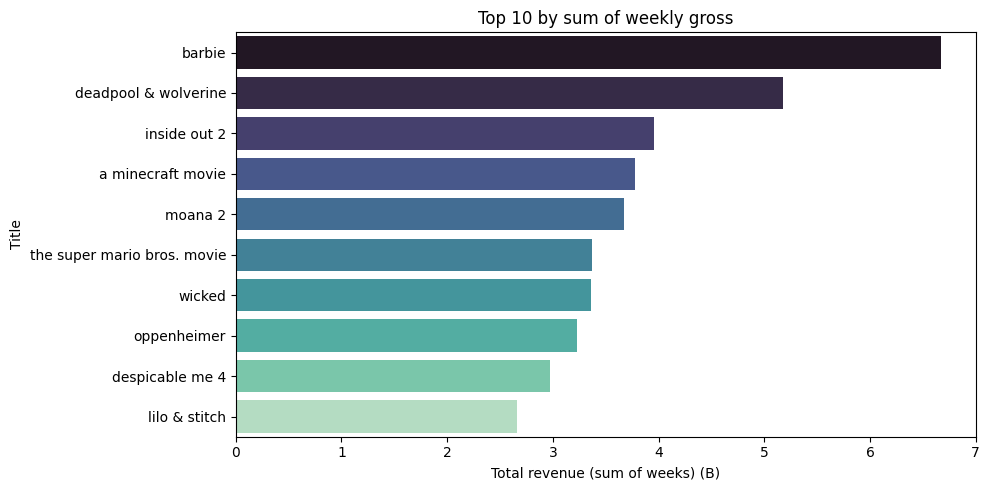

C:\Users\Nebula PC\AppData\Local\Temp\ipykernel_15116\1826029994.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=s_scaled.values, y=s_scaled.index, orient='h', palette='mako')


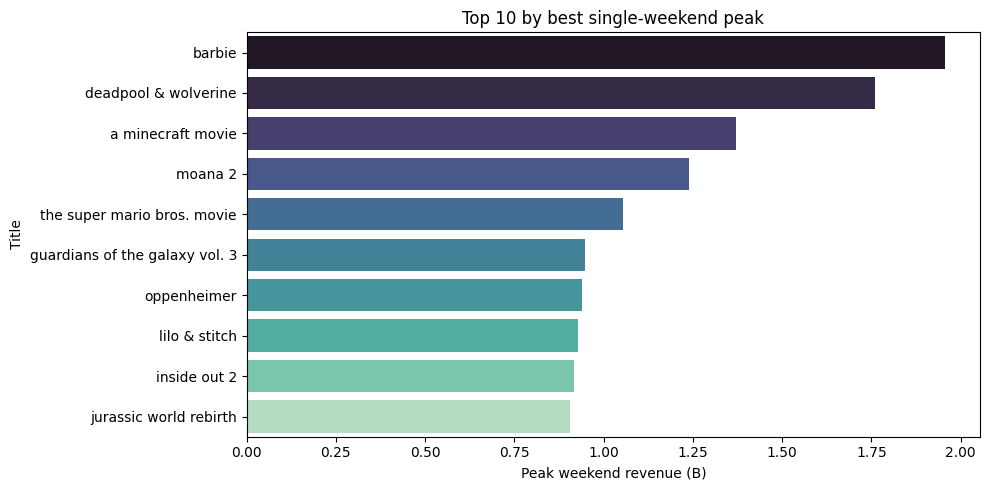

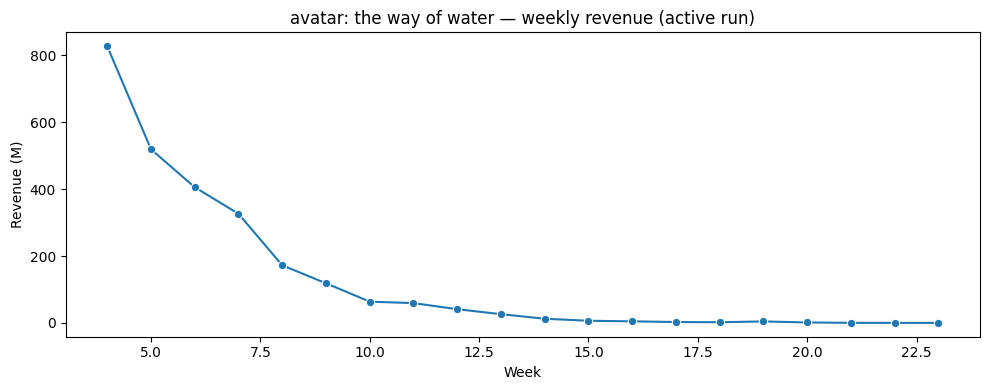

Plotted 20 periods for active run. Y-axis scaled to M.


In [ ]:
# Visualize the toplists and winner time series
def first_present(cands):
    return next((c for c in cands if c in df_flat.columns), None)

title_col = first_present(['title_norm','title','film_title','movie_title','title_name']) or first_present(['film_id','movie_id'])
week_col = first_present(['week','play_week','week_number','week_num','date','week_end_date'])
rev_week_col = first_present(['gross_weekend','weekend_gross','gross_week','gross','revenue_weekend'])
rev_cume_col = first_present(['cumulative_gross_weekend','cume_gross_weekend','total_gross','lifetime_gross'])

# Helper: auto-scale large currency values to K/M/B
def auto_scale(max_val: float):
    if pd.isna(max_val) or max_val <= 0:
        return 1.0, ''
    if max_val >= 1e9:
        return 1e9, 'B'
    if max_val >= 1e6:
        return 1e6, 'M'
    if max_val >= 1e3:
        return 1e3, 'K'
    return 1.0, ''

# Compute toplists 
top_cume = None
top_sum = None
top_peak = None
if rev_cume_col := rev_cume_col if 'rev_cume_col' in globals() else first_present(['cumulative_gross_weekend','cume_gross_weekend','total_gross','lifetime_gross']):
    top_cume = (df_flat.groupby(title_col, dropna=False)[rev_cume_col].max().sort_values(ascending=False).head(10))
if rev_week_col := rev_week_col if 'rev_week_col' in globals() else first_present(['gross_weekend','weekend_gross','gross_week','gross','revenue_weekend']):
    top_sum = (df_flat.groupby(title_col, dropna=False)[rev_week_col].sum().sort_values(ascending=False).head(10))
    top_peak = (df_flat.groupby(title_col, dropna=False)[rev_week_col].max().sort_values(ascending=False).head(10))

def barplot_series(s, title, base_xlabel):
    if s is None or s.empty:
        return
    scale, unit = auto_scale(float(np.nanmax(s.values)))
    s_scaled = s / scale
    plt.figure(figsize=(10, 5))
    sns.barplot(x=s_scaled.values, y=s_scaled.index, orient='h', palette='mako')
    plt.title(title)
    xlabel = base_xlabel + (f' ({unit})' if unit else '')
    plt.xlabel(xlabel)
    plt.ylabel('Title')
    plt.tight_layout()
    plt.show()

barplot_series(top_cume, 'Top 10 by cumulative total', 'Cumulative revenue')
barplot_series(top_sum, 'Top 10 by sum of weekly gross', 'Total revenue (sum of weeks)')
barplot_series(top_peak, 'Top 10 by best single-weekend peak', 'Peak weekend revenue')

# Winner time series
winner = None
if top_cume is not None:
    winner = top_cume.index[0]
elif top_sum is not None:
    winner = top_sum.index[0]
elif top_peak is not None:
    winner = top_peak.index[0]

if winner is not None and week_col and rev_week_col:
    df_w = df_flat.loc[df_flat[title_col] == winner, [week_col, rev_week_col]].copy()
    # Coerce textual dates to datetime
    if df_w[week_col].dtype == 'object':
        try:
            df_w[week_col] = pd.to_datetime(df_w[week_col], errors='coerce')
        except Exception:
            pass
    # Sort by time/week
    if np.issubdtype(df_w[week_col].dtype, np.datetime64):
        df_w = df_w.sort_values(week_col)
    else:
        df_w = df_w.sort_values(week_col, kind='mergesort')
    # Aggregate duplicate weeks by summing revenue
    df_w = df_w.groupby(week_col, as_index=False)[rev_week_col].sum()
    df_w['_pos'] = df_w[rev_week_col].fillna(0) > 0
    if df_w['_pos'].any():
        blocks = (df_w['_pos'] != df_w['_pos'].shift(fill_value=False)).cumsum()
        df_w['_block'] = blocks
        run_sizes = df_w.loc[df_w['_pos']].groupby('_block').size().sort_values(ascending=False)
        best_block = run_sizes.index[0]
        df_w = df_w[(df_w['_block'] == best_block) & (df_w['_pos'])].copy()
        df_w.drop(columns=['_pos','_block'], inplace=True)
    else:
        df_w = df_w.dropna(subset=[rev_week_col])

    # Auto-scale Y for readability
    ymax = float(df_w[rev_week_col].max()) if len(df_w) else 0.0
    scale, unit = auto_scale(ymax)
    plt.figure(figsize=(10,4))
    sns.lineplot(x=df_w[week_col], y=df_w[rev_week_col] / scale, marker='o')
    plt.title(f'{winner} — weekly revenue (active run)')
    plt.xlabel('Week' if not np.issubdtype(df_w[week_col].dtype, np.datetime64) else 'Date (weekly)')
    ylabel = 'Revenue' + (f' ({unit})' if unit else '')
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()
    print(f"Plotted {len(df_w)} periods for active run. Y-axis scaled to {unit or 'units'}.")
else:
    print('Winner time series skipped (missing week or weekly revenue column).')